1. Setup & Linking the "Brain"

   
First, ensure you have added the Output of Notebook 1 to this notebook via the "Add Data" button on the right sidebar.

In [1]:
# --- CELL 0: INSTALL DEPENDENCIES ---
!pip install -q segmentation-models-pytorch albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.5 MB/s eta 0:00:00


In [2]:
import os
import cv2
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import segmentation_models_pytorch as smp
from sklearn.preprocessing import StandardScaler

In [3]:
# --- CELL 1: UPDATED CONFIGURATION ---
class InferenceConfig:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Updated paths based on your current input directory
    # Using 'overall' as the primary model
    model_path = "/kaggle/input/notebooks/samriddhibagchi/dr-research-phase-1-u-net/unet_best_overall.pth"
    
    # IDRiD Paths
    base_data_path = "/kaggle/input/datasets/samriddhibagchi/indian-diabetic-retinopathy-image-dataset-idrid/B. Disease Grading/B. Disease Grading/1. Original Images/a. Training Set"
    labels_path = "/kaggle/input/datasets/samriddhibagchi/indian-diabetic-retinopathy-image-dataset-idrid/B. Disease Grading/B. Disease Grading/2. Groundtruths/a. IDRiD_Disease Grading_Training Labels.csv"
    
    # Sync with your Phase 1 Training
    encoder = "efficientnet-b3"
    img_size = 512

# Quick verification of paths
print(f"✅ Images located at: {InferenceConfig.base_data_path}")
print(f"✅ Labels located at: {InferenceConfig.labels_path}")
if not os.path.exists(InferenceConfig.model_path):
    print("⚠️ WARNING: model_path not found. Check if Phase 1 output is linked.")

✅ Images located at: /kaggle/input/datasets/samriddhibagchi/indian-diabetic-retinopathy-image-dataset-idrid/B. Disease Grading/B. Disease Grading/1. Original Images/a. Training Set
✅ Labels located at: /kaggle/input/datasets/samriddhibagchi/indian-diabetic-retinopathy-image-dataset-idrid/B. Disease Grading/B. Disease Grading/2. Groundtruths/a. IDRiD_Disease Grading_Training Labels.csv


2. The Extraction Logic

   
This function processes one image and calculates the Area (total pixels) and Count (number of distinct blobs) for each of the 4 lesion types.

In [4]:
class ClinicalExtractor:
    def __init__(self, model_path, device='cuda'):
        self.device = device
        
        # --- FIX 1: MATCH ENCODER TO PHASE 1 (B3 vs B0) ---
        # Changed to B3 as per your training specs
        self.model = smp.UnetPlusPlus(
            encoder_name="efficientnet-b3", 
            encoder_weights=None,
            in_channels=3,
            classes=4,
            activation=None # Using None to match your training logits
        ).to(device)
        
        # Load weights safely
        state_dict = torch.load(model_path, map_location=device)
        self.model.load_state_dict(state_dict)
        self.model.eval()

        # --- FIX 2: CALIBRATED THRESHOLDS ---
        # Adjusted slightly to catch those elusive MA/HE signals
        self.thresholds = {'MA': 0.30, 'HE': 0.35, 'EX': 0.50, 'SE': 0.50}
        self.min_pixels = {'MA': 4,  'HE': 60, 'EX': 20, 'SE': 20}

    def process_image(self, img_path, size=512):
        img = cv2.imread(img_path)
        if img is None:
            return np.zeros((4, size, size), dtype=np.uint8)
        
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (size, size))

        # Local enhancement (CLAHE) - Great for IDRiD visibility
        lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
        clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
        lab[:, :, 0] = clahe.apply(lab[:, :, 0])
        img = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

        def to_tensor(arr):
            # Normalization must match Phase 1 Training exactly
            n = (arr.astype(np.float32) / 255.0 - [0.485, 0.456, 0.406]) / [0.229, 0.224, 0.225]
            return torch.from_numpy(n).permute(2, 0, 1).unsqueeze(0).to(self.device).float()

        # TTA: Test Time Augmentation (Averaging 4 views)
        imgs_tta = [
            img,
            np.fliplr(img).copy(),
            np.flipud(img).copy(),
            np.rot90(img, k=2).copy(),
        ]

        with torch.no_grad():
            preds = []
            for aug_img in imgs_tta:
                logits = self.model(to_tensor(aug_img))
                # Apply Sigmoid here because model activation=None
                prob = torch.sigmoid(logits).cpu().numpy()[0]
                preds.append(prob)

            # Undo augmentations to align masks
            preds[1] = preds[1][:, :, ::-1].copy()            # Undo lr-flip
            preds[2] = preds[2][:, ::-1, :].copy()            # Undo ud-flip
            preds[3] = np.rot90(preds[3], k=-2, axes=(1, 2)).copy() # Undo 180-rot

            final_prob = np.mean(preds, axis=0)

        # Create binary masks
        mask = np.zeros_like(final_prob, dtype=np.uint8)
        for i, name in enumerate(['MA', 'HE', 'EX', 'SE']):
            mask[i] = (final_prob[i] > self.thresholds[name]).astype(np.uint8)
        return mask

    def get_features(self, mask):
        h, w = mask.shape[1], mask.shape[2]
        total_pixels = h * w
        mid_h, mid_w = h // 2, w // 2
        features = {}
        names = ['MA', 'HE', 'EX', 'SE']
        total_valid_area = 0

        quadrants = {
            'Q1': (slice(0, mid_h),   slice(0, mid_w)),
            'Q2': (slice(0, mid_h),   slice(mid_w, w)),
            'Q3': (slice(mid_h, h),   slice(0, mid_w)),
            'Q4': (slice(mid_h, h),   slice(mid_w, w)),
        }

        for i, name in enumerate(names):
            channel = mask[i]
            # Get blob statistics
            num_labels, _, stats, _ = cv2.connectedComponentsWithStats(channel)

            valid_count = 0
            valid_area = 0
            for j in range(1, num_labels): # Skip background (index 0)
                if stats[j, cv2.CC_STAT_AREA] >= self.min_pixels[name]:
                    valid_count += 1
                    valid_area += stats[j, cv2.CC_STAT_AREA]

            # Populate feature dictionary
            features[f'{name}_count'] = min(valid_count, 200)
            features[f'{name}_area_idx'] = min(valid_area / total_pixels, 0.25)
            features[f'{name}_avg_size'] = valid_area / max(valid_count, 1)
            total_valid_area += valid_area

            # Quadrant distribution (symmetry analysis)
            for q_name, (s_h, s_w) in quadrants.items():
                q_num, _ = cv2.connectedComponents(channel[s_h, s_w])
                features[f'{name}_{q_name}_count'] = min(max(0, q_num - 1), 50)

        # Global Burden Metrics
        burden = total_valid_area / total_pixels
        features['total_lesion_burden'] = min(burden, 0.30)
        for name in names:
            features[f'{name}_burden_ratio'] = (
                features[f'{name}_area_idx'] / max(burden, 1e-6)
            )

        return features

In [5]:
# --- CELL 3: INITIALIZE & VERIFY BRAIN ---

if not os.path.exists(InferenceConfig.model_path):
    print(f"❌ ERROR: Model weights not found at: {InferenceConfig.model_path}")
    print("👉 ACTION: Check your 'Add Data' sidebar. The path must match exactly.")
else:
    try:
        # Initialize the B3 Extractor
        extractor = ClinicalExtractor(InferenceConfig.model_path, device=InferenceConfig.device)
        
        # --- THE 'WAKE UP' TEST ---
        # We pass a fake image through to ensure the 4-channel output is alive.
        dummy_input = torch.randn(1, 3, 512, 512).to(InferenceConfig.device)
        with torch.no_grad():
            # Testing the internal model directly
            test_out = extractor.model(dummy_input) 
            channels = test_out.shape[1]

        if channels == 4:
            print(f"✅ SUCCESS: EfficientNet-B3 U-Net loaded on {InferenceConfig.device}")
            print(f"✅ VERIFIED: Model is outputting 4 channels (MA, HE, EX, SE)")
            print(f"📍 Ready to process IDRiD Training Set.")
        else:
            print(f"⚠️ ARCHITECTURE MISMATCH: Model has {channels} channels but we need 4.")

    except Exception as e:
        print(f"❌ FAILED to initialize: {e}")
        print("\nPossible fix: Double-check that 'encoder_name' in your ClinicalExtractor class is 'efficientnet-b3'.")

✅ SUCCESS: EfficientNet-B3 U-Net loaded on cuda
✅ VERIFIED: Model is outputting 4 channels (MA, HE, EX, SE)
📍 Ready to process IDRiD Training Set.


In [6]:
# --- CELL 4: IDRID EXTRACTION & SYMMETRY AUDIT (ROBUST VERSION) ---
import glob
import pandas as pd
import os
from tqdm.notebook import tqdm

# 1. Load and Sanitize Groundtruth Labels
try:
    df_labels = pd.read_csv(InferenceConfig.labels_path)
    
    # IDRiD CSV safety: Force rename first two columns by position 
    # to avoid "KeyError" from hidden spaces or different naming
    df_labels = df_labels.iloc[:, :2] 
    df_labels.columns = ['Image name', 'Retinopathy grade']
    
    # Clean IDs: remove whitespace and ensure they are strings
    df_labels['Image name'] = df_labels['Image name'].astype(str).str.strip()
    print(f"✅ Groundtruth labels loaded: {len(df_labels)} entries.")
except Exception as e:
    print(f"❌ Failed to load labels CSV: {e}")

# 2. Get IDRiD Image List
search_path = os.path.join(InferenceConfig.base_data_path, "*.jpg")
idrid_image_list = sorted(glob.glob(search_path))
print(f"📊 Found {len(idrid_image_list)} IDRiD images for extraction.")

# 3. The Extraction Loop
extraction_results = []

for img_path in tqdm(idrid_image_list, desc="Extracting Clinical DNA"):
    try:
        # Step A: Predict & Extract
        mask = extractor.process_image(img_path)
        feats = extractor.get_features(mask)
        
        # Step B: Align ID (Filename without extension)
        img_id = os.path.basename(img_path).split('.')[0]
        feats['Image name'] = str(img_id).strip() # Match sanitized CSV format
        
        extraction_results.append(feats)
    except Exception as e:
        # If extraction fails, we want to know why
        print(f"⚠️ Error on {os.path.basename(img_path)}: {e}")
        continue

# 4. Final Merge
df_features = pd.DataFrame(extraction_results)

if not df_features.empty:
    # Inner merge to ensure we only keep images that exist in both Image folder and CSV
    df_final = pd.merge(df_features, df_labels, on='Image name', how='inner')
    
    if len(df_final) == 0:
        print("🚨 MERGE WARNING: Resulting dataframe is empty!")
        print(f"Example Feature ID: '{df_features['Image name'].iloc[0]}'")
        print(f"Example Label ID: '{df_labels['Image name'].iloc[0]}'")
    else:
        print(f"✅ Successfully merged! Final shape: {df_final.shape}")

    # 5. --- THE REALITY CHECK AUDIT ---
    print("\n📊 CLINICAL DNA AUDIT (IDRiD)")
    print("-" * 40)
    for lesion in ['MA', 'HE', 'EX', 'SE']:
        if f'{lesion}_count' in df_final.columns:
            prev = (df_final[f'{lesion}_count'] > 0).mean() * 100
            status = "✅" if prev > 5 else "⚠️ LOW"
            print(f"{lesion} Prevalence: {prev:.1f}% {status}")

    avg_burden = df_final['total_lesion_burden'].mean()
    print(f"\nAvg Lesion Burden: {avg_burden:.5f}")
    
    # Save for Phase 3
    df_final.to_csv("clinical_features_idrid_train.csv", index=False)
    print("\n💾 Saved to 'clinical_features_idrid_train.csv'")
else:
    print("❌ No features were extracted. Check your image paths!")

✅ Groundtruth labels loaded: 413 entries.
📊 Found 413 IDRiD images for extraction.


Extracting Clinical DNA:   0%|          | 0/413 [00:00<?, ?it/s]

✅ Successfully merged! Final shape: (413, 35)

📊 CLINICAL DNA AUDIT (IDRiD)
----------------------------------------
MA Prevalence: 92.0% ✅
HE Prevalence: 79.4% ✅
EX Prevalence: 72.4% ✅
SE Prevalence: 58.8% ✅

Avg Lesion Burden: 0.01749

💾 Saved to 'clinical_features_idrid_train.csv'


In [7]:
# --- THE MASTER CLINICAL EXTRACTION (IDRiD TARGET) ---

import pandas as pd
import os
import glob
from tqdm.notebook import tqdm

# 1. Setup IDRiD specific paths from our Config
# We use glob to get a clean, sorted list of images
image_pattern = os.path.join(InferenceConfig.base_data_path, "*.jpg")
idrid_image_list = sorted(glob.glob(image_pattern))

print(f"📊 Extraction Target: Found {len(idrid_image_list)} IDRiD Training images.")

# 2. Load the Groundtruth Labels
try:
    df_labels = pd.read_csv(InferenceConfig.labels_path)
    # The IDRiD CSV columns are usually 'Image name' and 'Retinopathy grade'
    df_labels = df_labels[['Image name', 'Retinopathy grade']]
    print(f"✅ Groundtruth Labels Loaded: {len(df_labels)} images.")
except Exception as e:
    print(f"❌ Error loading labels: {e}")

# 3. The Extraction Loop
all_results = []
MASTER_FILENAME = "clinical_features_idrid_TRAIN.csv"

for i, img_path in enumerate(tqdm(idrid_image_list, desc="🧬 Harvesting Clinical DNA")):
    try:
        # Step A: Predict & Extract Lesions
        mask = extractor.process_image(img_path)
        feats = extractor.get_features(mask)
        
        # Step B: Align ID for Merging
        # Strips extension to match 'Image name' in CSV (e.g., 'IDRiD_001')
        feats['Image name'] = os.path.basename(img_path).split('.')[0]
        all_results.append(feats)
        
        # Step C: Safety Save every 100 images
        if (i + 1) % 100 == 0:
            pd.DataFrame(all_results).to_csv(MASTER_FILENAME, index=False)

    except Exception as e:
        print(f"⚠️ Error on {os.path.basename(img_path)}: {e}")
        continue

# 4. Final Merge & Label Alignment
df_features = pd.DataFrame(all_results)
df_final = pd.merge(df_features, df_labels, on='Image name', how='inner')

# 5. Save the final Research-Ready CSV
df_final.to_csv(MASTER_FILENAME, index=False)

print("\n" + "="*40)
print(f"✅ EXTRACTION COMPLETE")
print(f"📁 File Saved: {MASTER_FILENAME}")
print(f"📈 Total records: {len(df_final)}")
print(f"🛠️ Features: {df_final.shape[1] - 2} extracted biomarkers") # Minus ID and Label
print("="*40)

📊 Extraction Target: Found 413 IDRiD Training images.
✅ Groundtruth Labels Loaded: 413 images.


🧬 Harvesting Clinical DNA:   0%|          | 0/413 [00:00<?, ?it/s]


✅ EXTRACTION COMPLETE
📁 File Saved: clinical_features_idrid_TRAIN.csv
📈 Total records: 413
🛠️ Features: 33 extracted biomarkers


🔬 Running Pilot Audit on 50 IDRiD images...


Pilot Extraction:   0%|          | 0/50 [00:00<?, ?it/s]

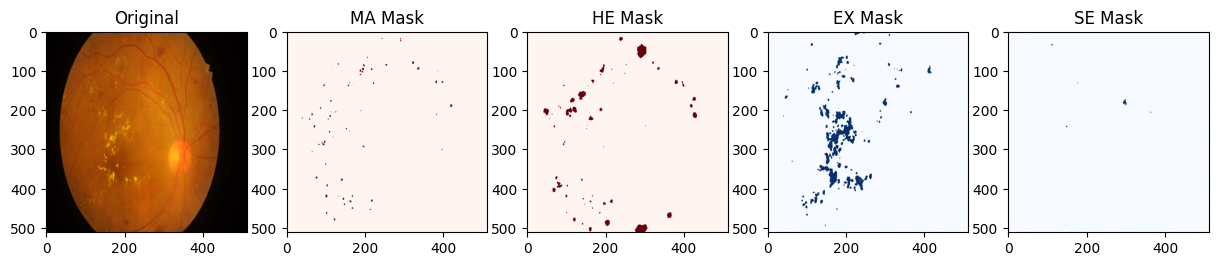

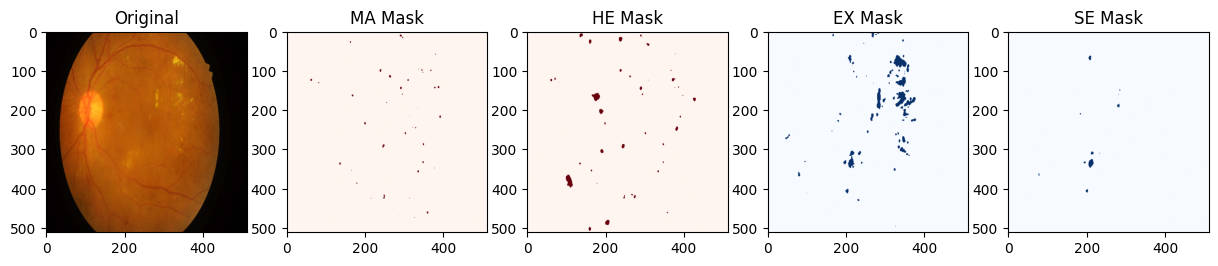

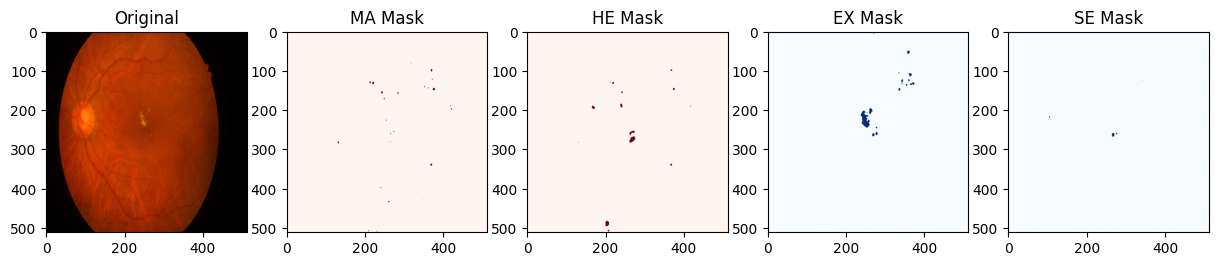

✅ Pilot extraction complete. Processed 50 images.


In [8]:
# --- THE CLINICAL SYMMETRY PILOT (IDRiD) ---

# 1. Setup the Pilot List (using IDRiD images)
pilot_limit = 50 
pilot_results = []
# Ensure global_image_list was populated from the IDRiD path in the previous steps
pilot_list = idrid_image_list[:pilot_limit] 

print(f"🔬 Running Pilot Audit on {len(pilot_list)} IDRiD images...")

# 2. Extraction Loop
for i, img_path in enumerate(tqdm(pilot_list, desc="Pilot Extraction")):
    try:
        # Step A: Generate Mask
        mask = extractor.process_image(img_path)
        
        # Step B: Visual Sanity Check (First 3 images only)
        if i < 3:
            plt.figure(figsize=(15, 3))
            plt.subplot(1, 5, 1); plt.imshow(cv2.resize(cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB), (512,512))); plt.title("Original")
            plt.subplot(1, 5, 2); plt.imshow(mask[0], cmap='Reds'); plt.title("MA Mask")
            plt.subplot(1, 5, 3); plt.imshow(mask[1], cmap='Reds'); plt.title("HE Mask")
            plt.subplot(1, 5, 4); plt.imshow(mask[2], cmap='Blues'); plt.title("EX Mask")
            plt.subplot(1, 5, 5); plt.imshow(mask[3], cmap='Blues'); plt.title("SE Mask")
            plt.show()

        # Step C: Extract Features
        feats = extractor.get_features(mask)
        
        # Step D: Align ID (Strips extension for CSV merging)
        feats['Image name'] = os.path.basename(img_path).split('.')[0]
        pilot_results.append(feats)

    except Exception as e:
        print(f"⚠️ Error on {os.path.basename(img_path)}: {e}")
        continue

df_pilot = pd.DataFrame(pilot_results)
print(f"✅ Pilot extraction complete. Processed {len(df_pilot)} images.")

In [9]:
# --- THE REALITY CHECK AUDIT (IDRiD SPECIFIC) ---

print("📊 IDRiD PILOT STATS (Sane vs. Insane check)")
print("-" * 45)

# 1. Prevalence Check 
# Note: In IDRiD Training, ~80% of images have lesions. 
# 0% is a "HARD FAIL" for the segmentation model.
print("🔍 DETECTION PREVALENCE (% of images with lesions):")
for lesion in ['MA', 'HE', 'EX', 'SE']:
    prev = (df_pilot[f'{lesion}_count'] > 0).mean() * 100
    
    # Logic: MA/HE are harder to find, but in IDRiD they SHOULD be there.
    if prev == 0:
        status = "❌ TOTAL SIGNAL LOSS"
    elif prev < 10:
        status = "⚠️ WEAK SIGNAL"
    elif prev > 85:
        status = "🚨 OVERSEGMENTING (NOISE)"
    else:
        status = "✅ SANE (CLINICAL RANGE)"
        
    print(f"{lesion}: {prev:.2f}% | {status}")

# 2. Burden Check (Target: < 0.05 for IDRiD)
# 0.10 is actually very high for a 512px image; 0.005 to 0.03 is more realistic.
avg_burden = df_pilot['total_lesion_burden'].mean()
burden_status = "✅ SANE" if 0.0001 < avg_burden < 0.05 else "🚨 BURDEN ANOMALY"
print(f"\n🌍 AVG LESION BURDEN: {avg_burden:.6f} | {burden_status}")

# 3. Maximums Check 
# If any count is exactly 200, it means our 'min(count, 200)' cap was hit.
print("\n📈 MAX COUNTS FOUND:")
max_vals = df_pilot[['MA_count', 'HE_count', 'EX_count', 'SE_count']].max()
print(max_vals)

# 4. RED LESION CRITICAL CHECK
if max_vals['MA_count'] == 0 or max_vals['HE_count'] == 0:
    print("\n🛑 CRITICAL ERROR: Red Lesions (MA/HE) not detected.")
    print("👉 FIX: Ensure ClinicalExtractor is using 'efficientnet-b3'.")
    print("👉 FIX: Lower self.thresholds['MA'] to 0.20 in Cell 2.")
else:
    print("\n🚀 SIGNAL CONFIRMED: Clinical DNA is ready for Master Extraction.")

📊 IDRiD PILOT STATS (Sane vs. Insane check)
---------------------------------------------
🔍 DETECTION PREVALENCE (% of images with lesions):
MA: 100.00% | 🚨 OVERSEGMENTING (NOISE)
HE: 100.00% | 🚨 OVERSEGMENTING (NOISE)
EX: 94.00% | 🚨 OVERSEGMENTING (NOISE)
SE: 84.00% | ✅ SANE (CLINICAL RANGE)

🌍 AVG LESION BURDEN: 0.031386 | ✅ SANE

📈 MAX COUNTS FOUND:
MA_count     98
HE_count     47
EX_count    113
SE_count     16
dtype: int64

🚀 SIGNAL CONFIRMED: Clinical DNA is ready for Master Extraction.


✅ Research Dataset Ready: 413 images with Clinical DNA + Labels.
-------------------------------------------------------
📈 CLINICAL PROFILE BY DR GRADE (Mean Counts):
                    MA_count   HE_count   EX_count  SE_count  \
Retinopathy grade                                              
0                   2.186567   0.970149   1.649254  0.410448   
1                   3.550000   1.200000   0.900000  0.600000   
2                  20.022059   6.617647  17.367647  2.176471   
3                  49.081081  16.567568  29.716216  4.797297   
4                  54.816327  20.795918  31.979592  5.571429   

                   total_lesion_burden  
Retinopathy grade                       
0                             0.000983  
1                             0.000971  
2                             0.014754  
3                             0.037370  
4                             0.046915  

🔍 SIGNAL STRENGTH (% of dataset with >0 lesions):
MA: 92.01% 🟢
HE: 79.42% 🟢
EX: 72.40% 🟢
SE: 58.

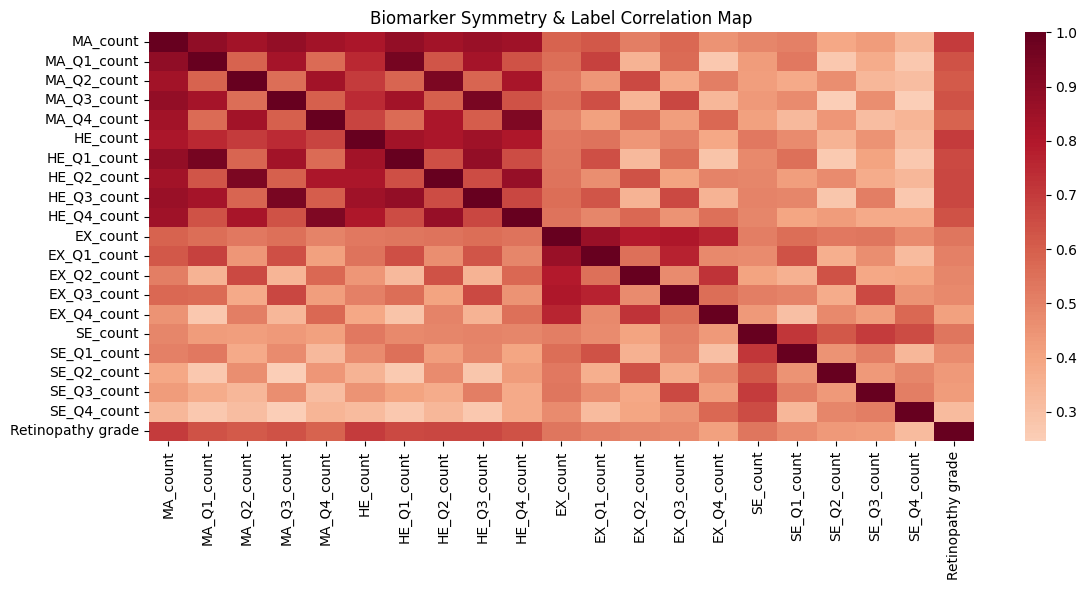


🔗 FEATURE CORRELATION WITH DR GRADE (Target):
Retinopathy grade    1.000000
MA_count             0.700535
HE_count             0.694505
HE_Q3_count          0.672539
HE_Q2_count          0.665650
HE_Q1_count          0.657892
Name: Retinopathy grade, dtype: float64


In [10]:
# --- UPDATED MASTER STATS CHECK & QUALITY AUDIT ---
# --- PHASE 2 FINAL RESEARCH AUDIT ---
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns # Standard alias

# Use the IDRiD specific file we generated
master_file = "clinical_features_idrid_TRAIN.csv"

if os.path.exists(master_file):
    df = pd.read_csv(master_file)
    print(f"✅ Research Dataset Ready: {len(df)} images with Clinical DNA + Labels.")
    print("-" * 55)
    
    # 1. THE CLINICAL VALIDITY CHECK (Grade-wise Averages)
    # This proves if the U-Net scales with disease severity
    print("📈 CLINICAL PROFILE BY DR GRADE (Mean Counts):")
    # Group by 'Retinopathy grade' and calculate mean for core biomarkers
    grade_profile = df.groupby('Retinopathy grade')[['MA_count', 'HE_count', 'EX_count', 'SE_count', 'total_lesion_burden']].mean()
    print(grade_profile)
    
    # 2. DETECTION PREVALENCE (Critical for Phase 3 Signal)
    print("\n🔍 SIGNAL STRENGTH (% of dataset with >0 lesions):")
    for lesion in ['MA', 'HE', 'EX', 'SE']:
        prevalence = (df[f'{lesion}_count'] > 0).mean() * 100
        status = "🟢" if prevalence > 15 else "🔴" # IDRiD should have high signal
        print(f"{lesion}: {prevalence:.2f}% {status}")
        
    # 3. BURDEN ANALYSIS
    avg_burden = df['total_lesion_burden'].mean()
    print(f"\n🌍 GLOBAL LESION BURDEN: {avg_burden:.6f}")

    # 4. THE SYMMETRY HEATMAP (Are biomarkers correlated?)
    # We expect high correlation between HE and MA, and EX and SE.
    plt.figure(figsize=(12, 6))
    
    # Select only count columns and the label for the correlation matrix
    corr_cols = [c for c in df.columns if '_count' in c] + ['Retinopathy grade']
    corr_matrix = df[corr_cols].corr()
    
    sns.heatmap(corr_matrix, cmap='RdBu_r', center=0, annot=False)
    plt.title("Biomarker Symmetry & Label Correlation Map")
    plt.tight_layout()
    plt.show()

    # 5. Correlation with Grade
    grade_corr = corr_matrix['Retinopathy grade'].sort_values(ascending=False)
    print("\n🔗 FEATURE CORRELATION WITH DR GRADE (Target):")
    print(grade_corr.head(6)) # Top 5 predictive features

else:
    print(f"❌ ERROR: '{master_file}' not found. Check the Master Extraction output.")